In [1]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [119]:
pip install --upgrade scikit-learn imbalanced-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.4/235.4 kB 3.3 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: imbalanced-learn
    Found existing installation: imbalanced-learn 0.12.3
    Uninstalling imbalanced-learn-0.12.3:
      Successfully uninstalled imbalanced-learn-0.12.3
Note: you may need to restart the kernel to use updated packages.


In [124]:
pip install eli5

Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#import dataset
df = pd.read_csv('watson_healthcare_modified.csv')

#import test dataset 
df_test = pd.read_csv('watson_shap_values_for_testset.csv')


In [4]:
df

,EmployeeID,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,Shift,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1313919,41,No,Travel_Rarely,1102,Cardiology,1,2,Life Sciences,1,...,1,80,0,8,0,1,6,4,0,5
1,1200302,49,No,Travel_Frequently,279,Maternity,8,1,Life Sciences,1,...,4,80,1,10,3,3,10,7,1,7
2,1060315,37,Yes,Travel_Rarely,1373,Maternity,2,2,Other,1,...,2,80,0,7,3,3,0,0,0,0
3,1272912,33,No,Travel_Frequently,1392,Maternity,3,4,Life Sciences,1,...,3,80,0,8,3,3,8,7,3,0
4,1414939,27,No,Travel_Rarely,591,Maternity,2,1,Medical,1,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1671,1117656,26,Yes,Travel_Rarely,471,Neurology,24,3,Technical Degree,1,...,2,80,0,1,3,1,1,0,0,0
1672,1152327,46,No,Travel_Rarely,1125,Cardiology,10,3,Marketing,1,...,3,80,1,15,3,3,3,2,1,2
1673,1812428,20,No,Travel_Rarely,959,Maternity,1,3,Life Sciences,1,...,4,80,0,1,0,4,1,0,0,0
1674,1812429,39,No,Travel_Rarely,466,Neurology,1,1,Life Sciences,1,...,3,80,1,21,3,3,21,6,11,8


In [5]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.2, random_state=5)

train_df.head()

,EmployeeID,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,Shift,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1573,1822238,28,No,Travel_Rarely,857,Maternity,10,3,Other,1,...,4,80,0,10,4,4,8,7,1,7
737,1631280,35,No,Travel_Rarely,802,Maternity,10,3,Other,1,...,1,80,1,3,4,2,3,2,1,2
947,1379068,31,No,Non-Travel,587,Cardiology,2,4,Life Sciences,1,...,1,80,1,10,5,2,10,8,9,6
404,1735186,28,No,Travel_Rarely,1300,Maternity,17,2,Medical,1,...,4,80,1,10,2,3,10,0,1,8
1540,1225300,45,No,Non-Travel,1195,Maternity,2,2,Medical,1,...,4,80,1,22,1,3,20,8,11,8


In [6]:
#target class no
No = train_df['Attrition'][train_df['Attrition'] == 'No']
print(No)


1573    No
737     No
947     No
404     No
1540    No
        ..
1424    No
1142    No
998     No
206     No
867     No
Name: Attrition, Length: 1180, dtype: object


In [7]:
#target class yes 
Yes = train_df['Attrition'][train_df['Attrition'] == 'Yes']
print(Yes)


124     Yes
136     Yes
2       Yes
1057    Yes
1652    Yes
       ... 
868     Yes
1134    Yes
1168    Yes
1278    Yes
204     Yes
Name: Attrition, Length: 160, dtype: object


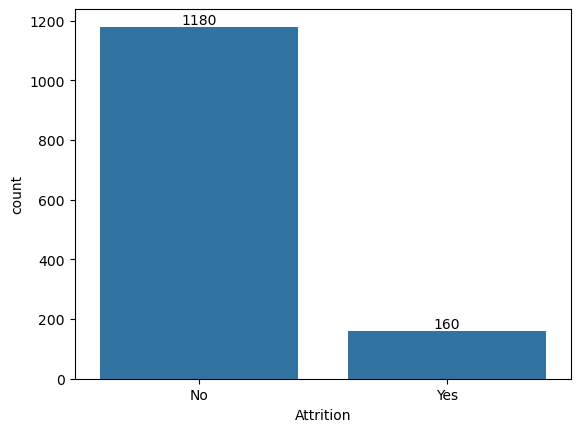

In [8]:
ax = sns.countplot(x ='Attrition', data = train_df)

for container in ax.containers:
    ax.bar_label(container)

plt.show()

In [9]:
train_df.columns

Index(['EmployeeID', 'Age', 'Attrition', 'BusinessTravel', 'DailyRate',
       'Department', 'DistanceFromHome', 'Education', 'EducationField',
       'EmployeeCount', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'Shift',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [10]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1340 entries, 1573 to 867
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   EmployeeID                1340 non-null   int64 
 1   Age                       1340 non-null   int64 
 2   Attrition                 1340 non-null   object
 3   BusinessTravel            1340 non-null   object
 4   DailyRate                 1340 non-null   int64 
 5   Department                1340 non-null   object
 6   DistanceFromHome          1340 non-null   int64 
 7   Education                 1340 non-null   int64 
 8   EducationField            1340 non-null   object
 9   EmployeeCount             1340 non-null   int64 
 10  EnvironmentSatisfaction   1340 non-null   int64 
 11  Gender                    1340 non-null   object
 12  HourlyRate                1340 non-null   int64 
 13  JobInvolvement            1340 non-null   int64 
 14  JobLevel                  1

array([[<Axes: title={'center': 'EmployeeID'}>,
        <Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'DailyRate'}>,
        <Axes: title={'center': 'DistanceFromHome'}>,
        <Axes: title={'center': 'Education'}>],
       [<Axes: title={'center': 'EmployeeCount'}>,
        <Axes: title={'center': 'EnvironmentSatisfaction'}>,
        <Axes: title={'center': 'HourlyRate'}>,
        <Axes: title={'center': 'JobInvolvement'}>,
        <Axes: title={'center': 'JobLevel'}>],
       [<Axes: title={'center': 'JobSatisfaction'}>,
        <Axes: title={'center': 'MonthlyIncome'}>,
        <Axes: title={'center': 'MonthlyRate'}>,
        <Axes: title={'center': 'NumCompaniesWorked'}>,
        <Axes: title={'center': 'PercentSalaryHike'}>],
       [<Axes: title={'center': 'PerformanceRating'}>,
        <Axes: title={'center': 'RelationshipSatisfaction'}>,
        <Axes: title={'center': 'StandardHours'}>,
        <Axes: title={'center': 'Shift'}>,
        <Axes: title={'cent

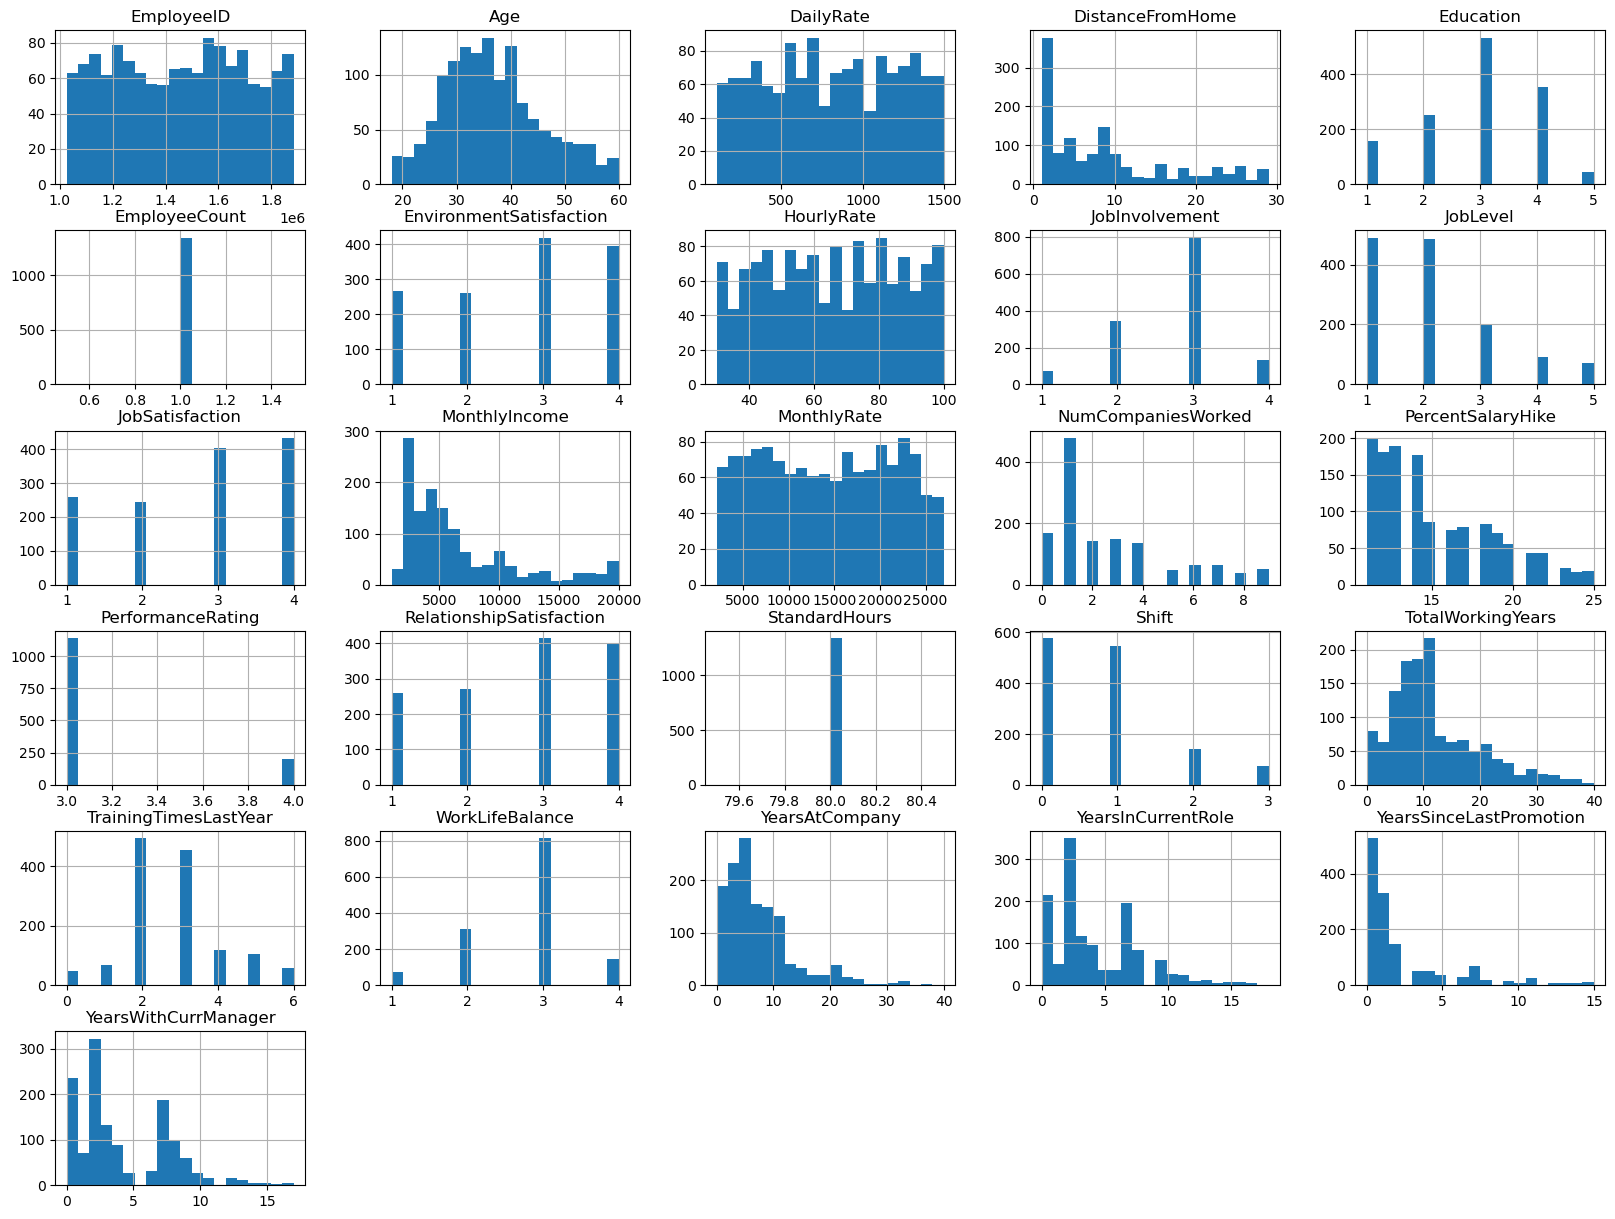

In [11]:
train_df.hist(bins=20, figsize=(20,15))

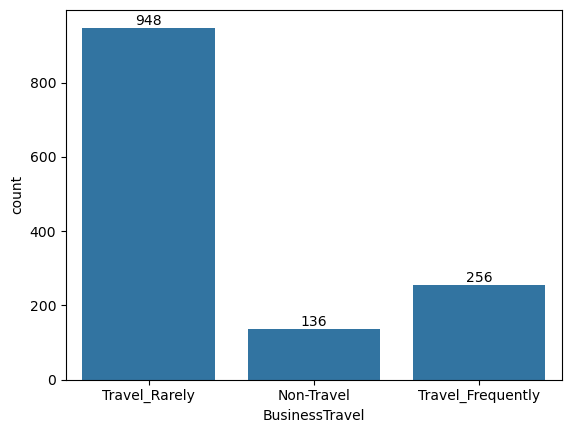

In [12]:
# Create the plot and capture the Axes object
ax = sns.countplot(x ='BusinessTravel', data = train_df)

# Add labels to each bar container
for container in ax.containers:
    ax.bar_label(container)
    
plt.show()


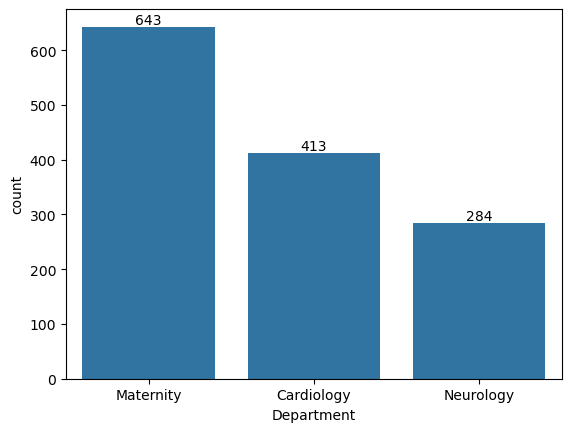

In [13]:
ax = sns.countplot(x ='Department', data = train_df)

for container in ax.containers:
    ax.bar_label(container)
    
plt.show()


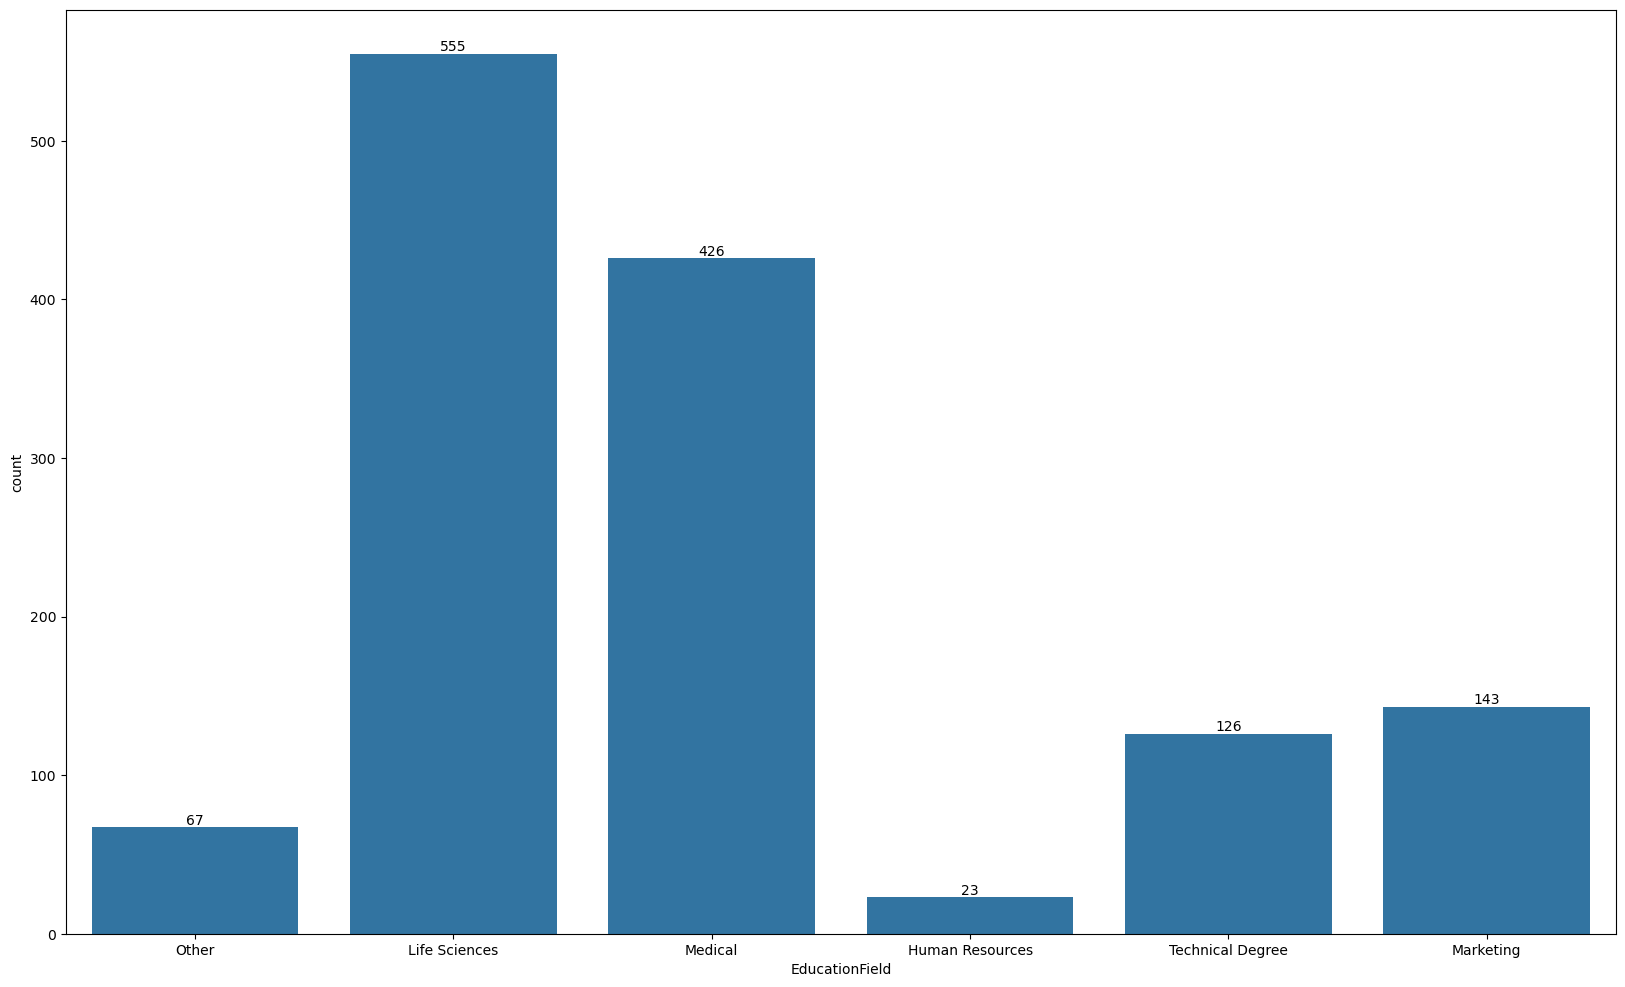

In [14]:
plt.figure(figsize=(20, 12))
ax = sns.countplot(x ='EducationField', data = train_df)

for container in ax.containers:
    ax.bar_label(container)
    
plt.show()



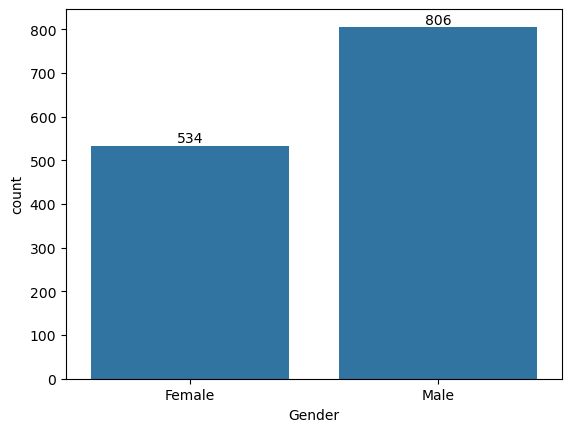

In [15]:
ax = sns.countplot(x ='Gender', data = train_df)

for container in ax.containers:
    ax.bar_label(container)
    
plt.show()

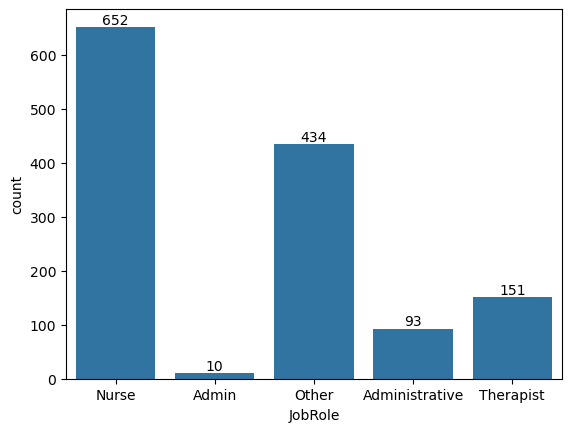

In [16]:
ax = sns.countplot(x ='JobRole', data = train_df)

for container in ax.containers:
    ax.bar_label(container)
    
plt.show()

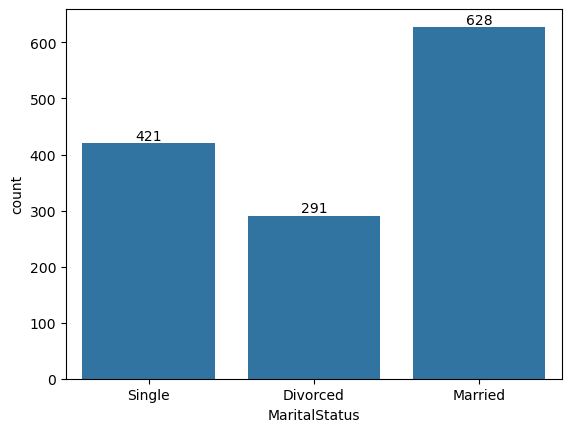

In [17]:
ax = sns.countplot(x ='MaritalStatus', data = train_df)

for container in ax.containers:
    ax.bar_label(container)
    
plt.show()

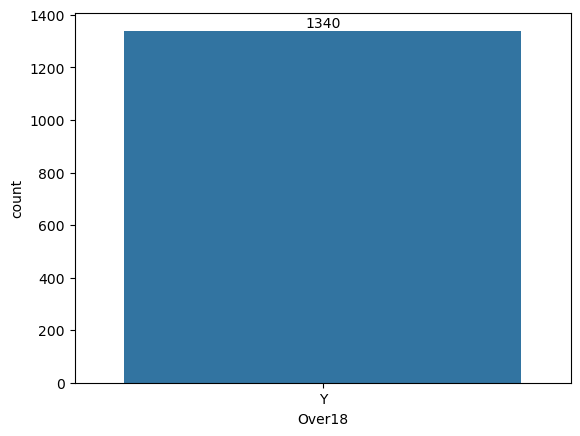

In [18]:
ax = sns.countplot(x ='Over18', data = train_df)

for container in ax.containers:
    ax.bar_label(container)
    
plt.show()

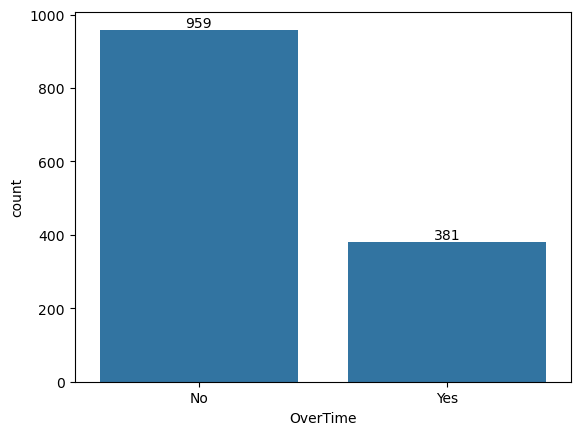

In [19]:
ax = sns.countplot(x ='OverTime', data = train_df)

for container in ax.containers:
    ax.bar_label(container)
    
plt.show()

In [24]:
#exploring the test set provided by Kaggle though choice was made to split the original 
df_test

,EmployeeID,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,...,RelationshipSatisfaction,ShiftSchedule,State,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,10011,-0.082934,-0.049007,0.033110,-0.052101,-0.094783,-0.007782,-0.056123,0,-0.106410,...,0.109181,-0.195666,0.056648,0.011107,-0.017621,-0.000377,-0.032997,0.003732,-0.042552,-0.120689
1,10012,-0.061724,-0.185156,0.004095,-0.055188,-0.063846,-0.032673,-0.057622,0,-0.025947,...,-0.035909,-0.169545,0.043217,0.079458,-0.052512,-0.043295,0.060303,0.016709,-0.037952,0.152560
2,10013,0.006087,-0.057510,0.017782,-0.002091,-0.008152,-0.028928,-0.070993,0,-0.042936,...,-0.038788,-0.169869,0.099417,-0.009016,-0.046488,-0.080971,-0.022697,0.007191,-0.037359,-0.110958
3,10014,-0.012834,0.242323,-0.044950,-0.039829,-0.133996,-0.034905,-0.051805,0,-0.053241,...,-0.024949,0.165522,0.033103,-0.006922,-0.044399,-0.036111,-0.074827,-0.025470,0.004950,-0.036003
4,10015,-0.035391,-0.023601,0.014274,0.015462,-0.138073,0.007920,0.052945,0,-0.072430,...,-0.022945,0.126107,0.101879,-0.028295,-0.055819,-0.049084,-0.013705,0.011744,-0.039383,-0.054550
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
201,10212,-0.039493,-0.034747,-0.044727,-0.022448,-0.117214,0.029679,-0.013860,0,-0.049312,...,-0.058096,-0.161909,-0.030475,-0.034089,-0.044657,-0.042839,-0.041159,-0.042855,-0.054734,-0.049729
202,10213,-0.091602,-0.053394,-0.107608,-0.053622,-0.109185,-0.012358,-0.083148,0,-0.023243,...,-0.028543,-0.160014,-0.005274,-0.015650,-0.028211,-0.015259,-0.041551,-0.032326,0.159189,-0.051259
203,10214,0.249557,-0.104146,0.015778,-0.091577,0.014157,0.022667,-0.102058,0,0.301851,...,-0.012861,0.224978,-0.058046,0.083066,0.003723,0.042219,0.120966,0.033763,-0.022962,0.393495
204,10215,-0.015204,-0.034563,-0.025504,-0.055249,-0.047021,0.015875,-0.072875,0,-0.042504,...,-0.041672,0.102638,0.077688,-0.035025,-0.009765,-0.055626,-0.028669,-0.031676,0.194487,-0.073237


In [25]:
df_test.columns

Index(['EmployeeID', 'Age', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeNumber',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'ShiftSchedule', 'State', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

In [32]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206 entries, 0 to 205
Data columns (total 33 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmployeeID                206 non-null    int64  
 1   Age                       206 non-null    float64
 2   BusinessTravel            206 non-null    float64
 3   DailyRate                 206 non-null    float64
 4   Department                206 non-null    float64
 5   DistanceFromHome          206 non-null    float64
 6   Education                 206 non-null    float64
 7   EducationField            206 non-null    float64
 8   EmployeeNumber            206 non-null    int64  
 9   EnvironmentSatisfaction   206 non-null    float64
 10  Gender                    206 non-null    float64
 11  HourlyRate                206 non-null    float64
 12  JobInvolvement            206 non-null    float64
 13  JobLevel                  206 non-null    float64
 14  JobRole   

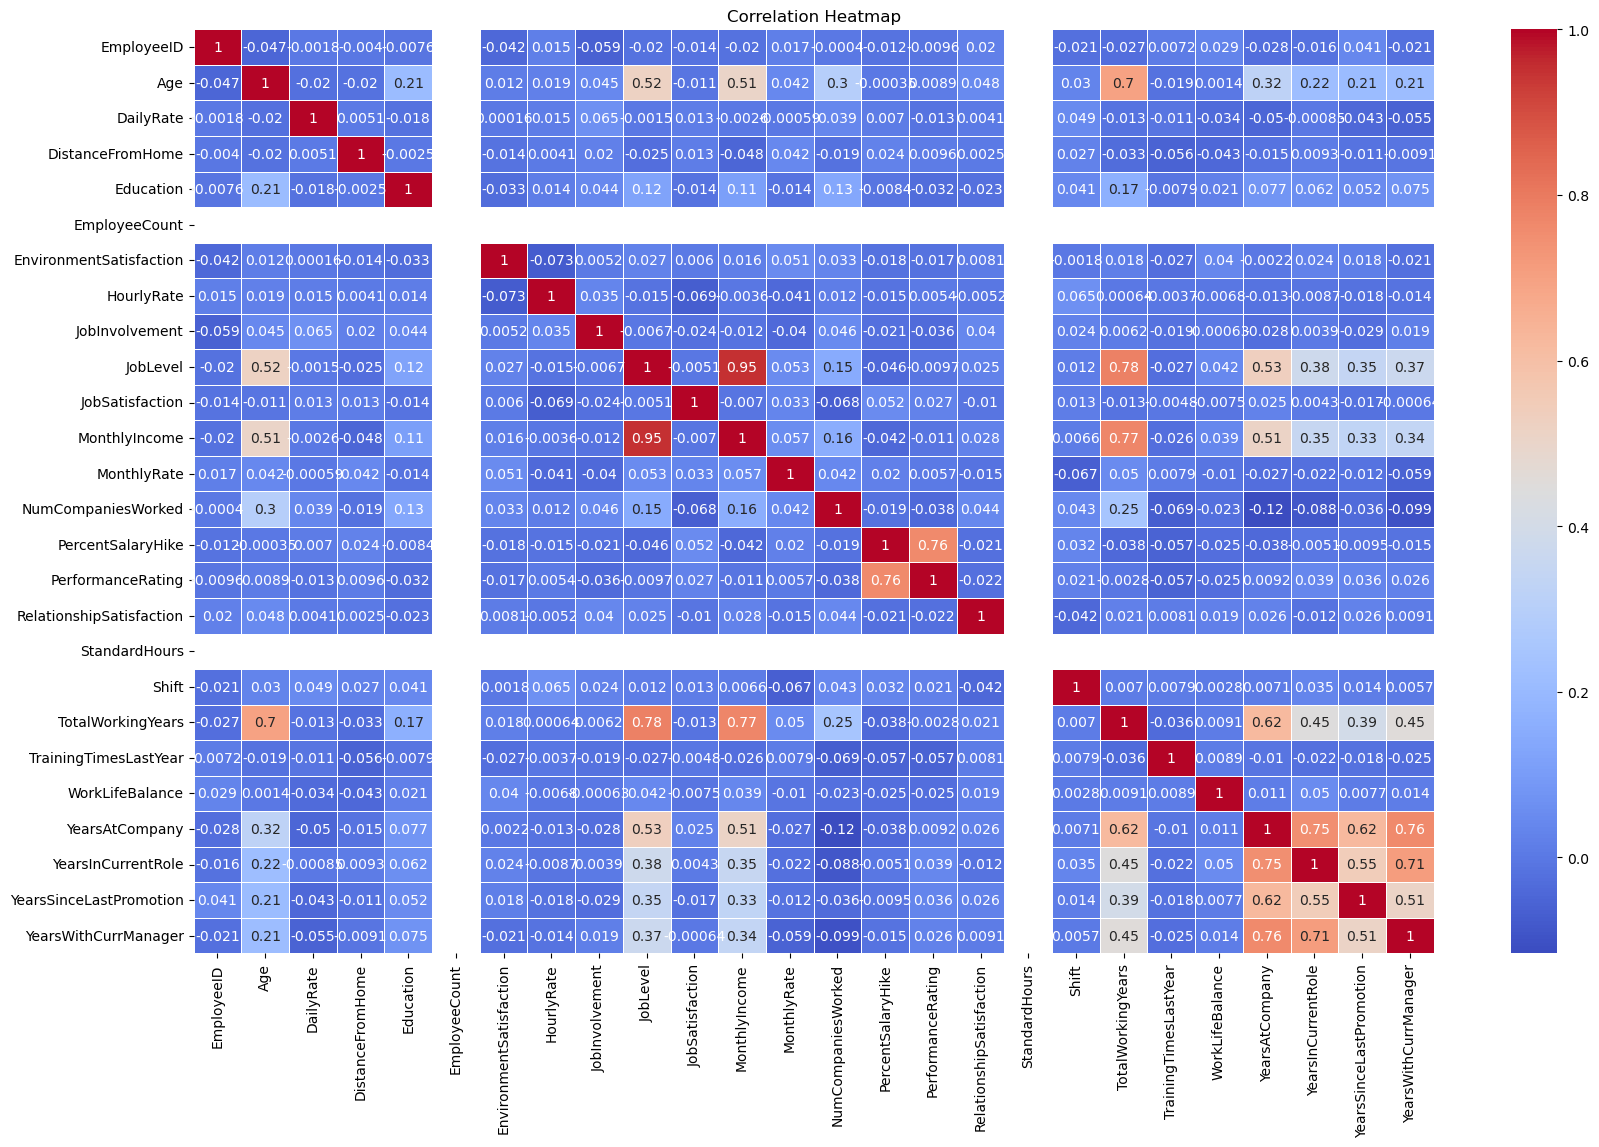

In [48]:
#heat map to determine correlations for feature selection 
correlation_matrix = train_df.corr(numeric_only=True)
plt.figure(figsize=(20, 12)) # Optional: Adjust the size of the plot
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap') # Optional: Add a title
plt.savefig('Correlation Heatmap')
plt.show()

In [49]:
train_df.columns

Index(['EmployeeID', 'Age', 'Attrition', 'BusinessTravel', 'DailyRate',
       'Department', 'DistanceFromHome', 'Education', 'EducationField',
       'EmployeeCount', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'Shift',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [50]:
#removing columns due to redundancy
columns_to_drop = ['EmployeeID', 'EmployeeCount', 'Over18', 'DailyRate', 'MonthlyRate', 'PerformanceRating', 'StandardHours', 'JobLevel', 'YearsWithCurrManager', 'YearsInCurrentRole', 'TotalWorkingYears', 'PercentSalaryHike']
train_df = train_df.drop(columns=['EmployeeID', 'EmployeeCount', 'Over18', 'DailyRate', 'MonthlyRate', 'PerformanceRating', 'StandardHours', 'JobLevel', 'YearsWithCurrManager', 'YearsInCurrentRole', 'TotalWorkingYears', 'PercentSalaryHike']) 

test_df = test_df.drop(columns=['EmployeeID', 'EmployeeCount', 'Over18', 'DailyRate', 'MonthlyRate', 'PerformanceRating', 'StandardHours', 'JobLevel', 'YearsWithCurrManager', 'YearsInCurrentRole', 'TotalWorkingYears', 'PercentSalaryHike']) 


In [51]:
train_df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'Department', 'DistanceFromHome',
       'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender',
       'HourlyRate', 'JobInvolvement', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'NumCompaniesWorked', 'OverTime',
       'RelationshipSatisfaction', 'Shift', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsSinceLastPromotion'],
      dtype='object')

In [52]:
test_df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'Department', 'DistanceFromHome',
       'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender',
       'HourlyRate', 'JobInvolvement', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'NumCompaniesWorked', 'OverTime',
       'RelationshipSatisfaction', 'Shift', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsSinceLastPromotion'],
      dtype='object')

In [58]:
train_df.head()

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,...,MaritalStatus,MonthlyIncome,NumCompaniesWorked,OverTime,RelationshipSatisfaction,Shift,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsSinceLastPromotion
1573,28,No,Travel_Rarely,Maternity,10,3,Other,3,Female,59,...,Single,3660,3,No,4,0,4,4,8,1
737,35,No,Travel_Rarely,Maternity,10,3,Other,2,Male,45,...,Divorced,3917,1,No,1,1,4,2,3,1
947,31,No,Non-Travel,Cardiology,2,4,Life Sciences,4,Female,57,...,Divorced,9852,1,Yes,1,1,5,2,10,9
404,28,No,Travel_Rarely,Maternity,17,2,Medical,3,Male,79,...,Divorced,4558,1,No,4,1,2,3,10,1
1540,45,No,Non-Travel,Maternity,2,2,Medical,1,Male,65,...,Married,16792,9,No,4,1,1,3,20,11


In [60]:
test_df.head()

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,...,MaritalStatus,MonthlyIncome,NumCompaniesWorked,OverTime,RelationshipSatisfaction,Shift,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsSinceLastPromotion
1097,35,No,Travel_Rarely,Cardiology,28,4,Life Sciences,2,Female,98,...,Married,2430,0,No,1,2,5,3,5,4
1521,47,No,Travel_Rarely,Maternity,25,3,Medical,1,Male,84,...,Single,8633,2,No,2,0,3,3,17,12
855,53,No,Travel_Rarely,Neurology,7,2,Medical,4,Female,50,...,Divorced,18606,3,No,2,1,6,3,7,4
1150,18,Yes,Travel_Frequently,Cardiology,3,2,Medical,2,Female,70,...,Single,1569,1,Yes,3,0,2,4,0,0
315,43,No,Travel_Frequently,Maternity,10,4,Life Sciences,3,Female,33,...,Single,2455,0,No,1,0,5,3,8,1


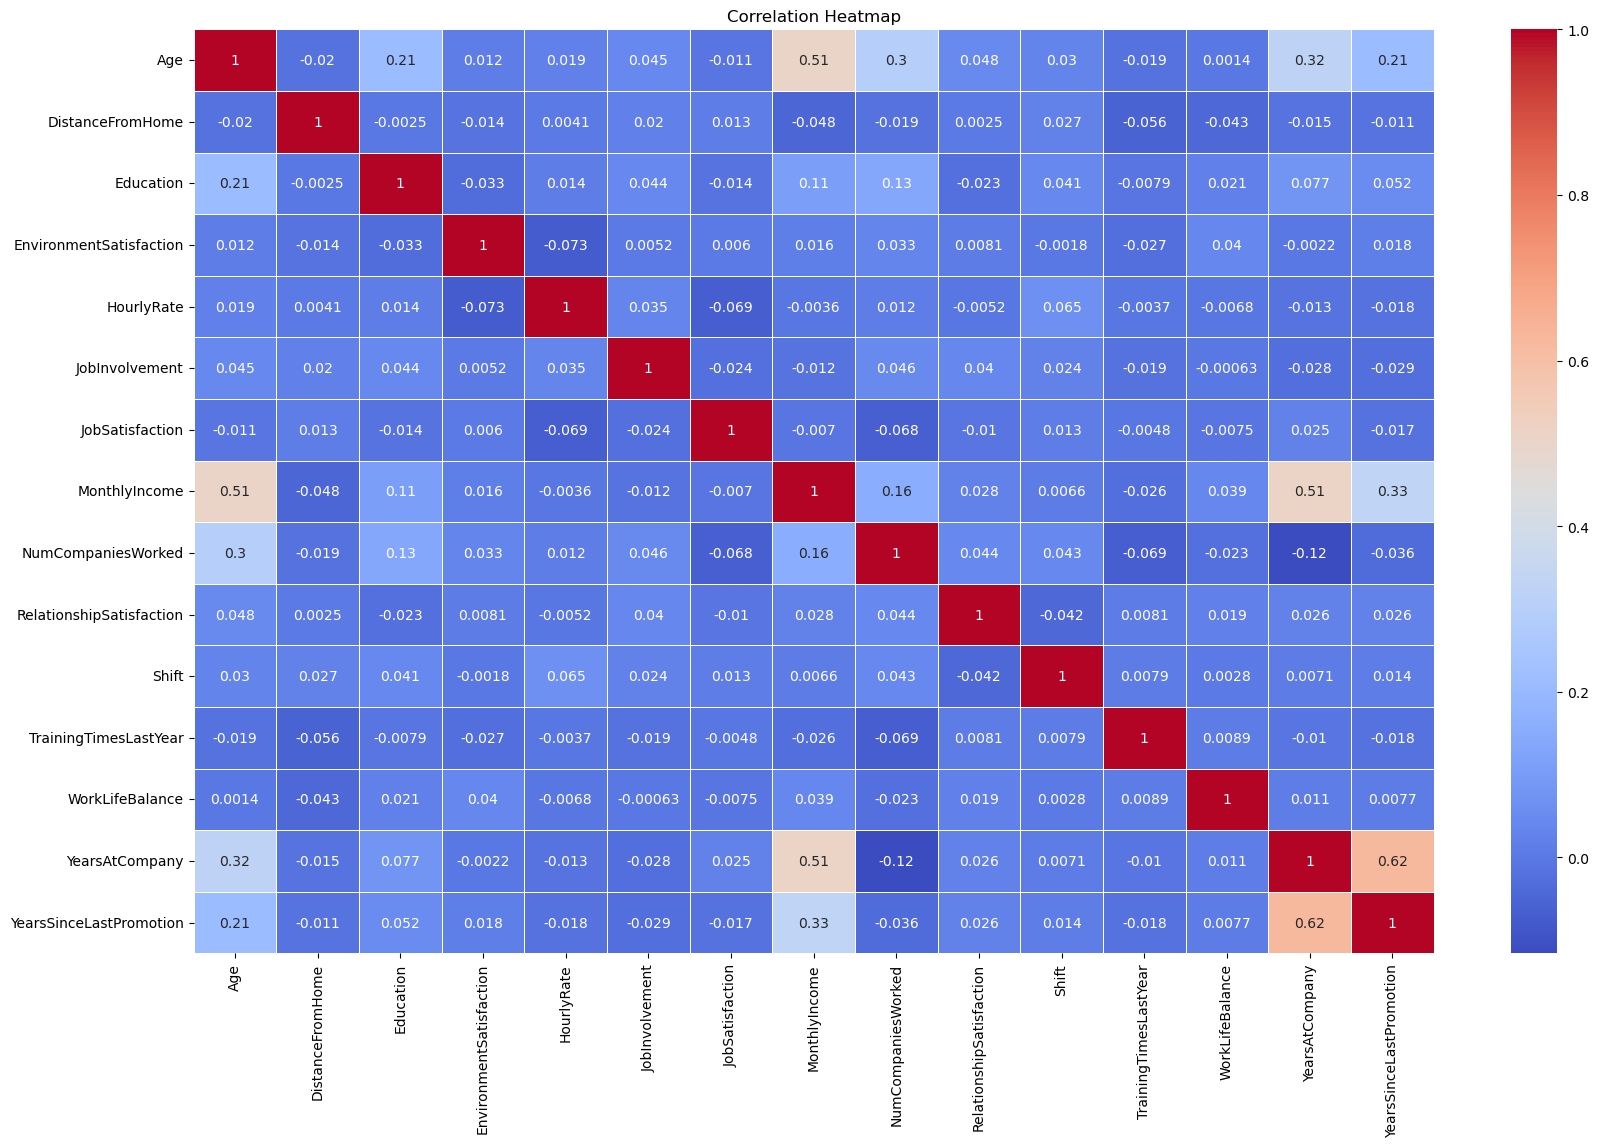

In [61]:
correlation_matrix = train_df.corr(numeric_only=True)
plt.figure(figsize=(20, 12)) # Optional: Adjust the size of the plot
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap') # Optional: Add a title
plt.savefig('Correlation Heatmap')
plt.show()

In [64]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1340 entries, 1573 to 867
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1340 non-null   int64 
 1   Attrition                 1340 non-null   object
 2   BusinessTravel            1340 non-null   object
 3   Department                1340 non-null   object
 4   DistanceFromHome          1340 non-null   int64 
 5   Education                 1340 non-null   int64 
 6   EducationField            1340 non-null   object
 7   EnvironmentSatisfaction   1340 non-null   int64 
 8   Gender                    1340 non-null   object
 9   HourlyRate                1340 non-null   int64 
 10  JobInvolvement            1340 non-null   int64 
 11  JobRole                   1340 non-null   object
 12  JobSatisfaction           1340 non-null   int64 
 13  MaritalStatus             1340 non-null   object
 14  MonthlyIncome             1

In [66]:
train_df.describe()

,Age,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobSatisfaction,MonthlyIncome,NumCompaniesWorked,RelationshipSatisfaction,Shift,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsSinceLastPromotion
count,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000
mean,36.797015,9.114179,2.907463,2.702239,65.306716,2.732836,2.753731,6581.788806,2.694776,2.708955,0.788806,2.800000,2.764179,7.044776,2.162687
std,9.127623,8.056908,1.020523,1.094556,20.300081,0.706502,1.104925,4753.702791,2.479816,1.088501,0.848155,1.274909,0.708152,6.135836,3.190788
min,18.000000,1.000000,1.000000,1.000000,30.000000,1.000000,1.000000,1009.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,30.000000,2.000000,2.000000,2.000000,48.000000,2.000000,2.000000,2972.750000,1.000000,2.000000,0.000000,2.000000,2.000000,3.000000,0.000000
50%,35.000000,7.000000,3.000000,3.000000,65.000000,3.000000,3.000000,4936.000000,2.000000,3.000000,1.000000,3.000000,3.000000,5.000000,1.000000
75%,42.250000,13.000000,4.000000,4.000000,83.000000,3.000000,4.000000,8585.000000,4.000000,4.000000,1.000000,3.000000,3.000000,9.000000,2.250000
max,60.000000,29.000000,5.000000,4.000000,100.000000,4.000000,4.000000,19999.000000,9.000000,4.000000,3.000000,6.000000,4.000000,40.000000,15.000000


In [67]:
#Need to transform categorical data and normalize data. There are no missing values. 

#Convert Gender to numbers 
gender=[x for x in train_df['Gender']]
for x in range(1340):
    if gender[x]=='Male':
        gender[x]=int(0)
    else:
        gender[x]=int(1)
train_df['Gender']= gender

#Convert OverTime to numbers 
overtime=[x for x in train_df['OverTime']]
for x in range(1340):
    if overtime[x]=='Yes':
        overtime[x]=int(1)
    else:
        overtime[x]=int(0)
train_df['OverTime']=overtime

#Convert Attrition to numbers 
attrition=[x for x in train_df['Attrition']]
for x in range(1340):
    if attrition[x]=='Yes':
        attrition[x]=int(1)
    else:
        attrition[x]=int(0)
train_df['Attrition']=attrition

In [70]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1340 entries, 1573 to 867
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1340 non-null   int64 
 1   Attrition                 1340 non-null   int64 
 2   BusinessTravel            1340 non-null   object
 3   Department                1340 non-null   object
 4   DistanceFromHome          1340 non-null   int64 
 5   Education                 1340 non-null   int64 
 6   EducationField            1340 non-null   object
 7   EnvironmentSatisfaction   1340 non-null   int64 
 8   Gender                    1340 non-null   int64 
 9   HourlyRate                1340 non-null   int64 
 10  JobInvolvement            1340 non-null   int64 
 11  JobRole                   1340 non-null   object
 12  JobSatisfaction           1340 non-null   int64 
 13  MaritalStatus             1340 non-null   object
 14  MonthlyIncome             1

In [72]:
#Need to transform categorical data for test data. 

#Convert Gender to numbers 
gender=[x for x in test_df['Gender']]
for x in range(336):
    if gender[x]=='Male':
        gender[x]=int(0)
    else:
        gender[x]=int(1)
test_df['Gender']= gender

#Convert OverTime to numbers 
overtime=[x for x in test_df['OverTime']]
for x in range(336):
    if overtime[x]=='Yes':
        overtime[x]=int(1)
    else:
        overtime[x]=int(0)
test_df['OverTime']=overtime

#Convert Attrition to numbers 
attrition=[x for x in test_df['Attrition']]
for x in range(336):
    if attrition[x]=='Yes':
        attrition[x]=int(1)
    else:
        attrition[x]=int(0)
test_df['Attrition']=attrition

In [74]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 336 entries, 1097 to 864
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       336 non-null    int64 
 1   Attrition                 336 non-null    int64 
 2   BusinessTravel            336 non-null    object
 3   Department                336 non-null    object
 4   DistanceFromHome          336 non-null    int64 
 5   Education                 336 non-null    int64 
 6   EducationField            336 non-null    object
 7   EnvironmentSatisfaction   336 non-null    int64 
 8   Gender                    336 non-null    int64 
 9   HourlyRate                336 non-null    int64 
 10  JobInvolvement            336 non-null    int64 
 11  JobRole                   336 non-null    object
 12  JobSatisfaction           336 non-null    int64 
 13  MaritalStatus             336 non-null    object
 14  MonthlyIncome             33

In [76]:
#Time to Make Pipeline


from imblearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import ADASYN


categorical_feat = ['BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus']
numerical_feat = ['Age', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobSatisfaction', 'MonthlyIncome', 'NumCompaniesWorked', 'OverTime', 'RelationshipSatisfaction', 'Shift', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsSinceLastPromotion']

ct=make_column_transformer(
                            (OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_feat), 
                            (StandardScaler(), numerical_feat)
                          )
ct

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('onehotencoder', ...), ('standardscaler', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``f

In [78]:
pipe_rf = Pipeline(
    steps=[
        ("column_transform", ct),
        ("adasyn", ADASYN()),
        ("classifier", RandomForestClassifier(n_estimators=100)),
    ]
)

pipe_rf

,steps,"[('column_transform', ...), ('adasyn', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('onehotencoder', ...), ('standardscaler', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string

In [79]:
from sklearn.neural_network import MLPClassifier

pipe_nn = Pipeline(
    steps=[
        ("column_transform", ct),
        ("adasyn", ADASYN()),
        ("classifier", MLPClassifier(hidden_layer_sizes=(22,), max_iter=1000))
    ]
)

pipe_nn

,steps,"[('column_transform', ...), ('adasyn', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('onehotencoder', ...), ('standardscaler', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string

In [83]:
#Create training samples and target class
X_train = train_df.drop(columns=['Attrition'])
y_train = train_df['Attrition']

In [86]:
X_test = test_df.drop(columns=['Attrition'])
y_test = test_df['Attrition']

In [88]:
X_train.columns

Index(['Age', 'BusinessTravel', 'Department', 'DistanceFromHome', 'Education',
       'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'NumCompaniesWorked', 'OverTime',
       'RelationshipSatisfaction', 'Shift', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsSinceLastPromotion'],
      dtype='object')

In [90]:
X_test.columns

Index(['Age', 'BusinessTravel', 'Department', 'DistanceFromHome', 'Education',
       'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'NumCompaniesWorked', 'OverTime',
       'RelationshipSatisfaction', 'Shift', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsSinceLastPromotion'],
      dtype='object')

In [93]:
#Train both models 
pipe_rf.fit(X_train, y_train)
pipe_nn.fit(X_train, y_train)

,steps,"[('column_transform', ...), ('adasyn', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('onehotencoder', ...), ('standardscaler', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string

In [95]:
#Test current accuracy 
print(f"Random Forest test accuracy: {pipe_rf.score(X_test, y_test):.3f}")

Random Forest test accuracy: 0.923


In [97]:
#Test current accuracy 
print(f"Neural Network test accuracy: {pipe_nn.score(X_test, y_test):.3f}")

Neural Network test accuracy: 0.911


In [99]:
#Test current recall
from sklearn.metrics import recall_score
y_pred = pipe_rf.predict(X_test)
print(f"Random Forest test recall: {recall_score(y_test, y_pred)}")

Random Forest test recall: 0.5128205128205128


In [101]:
#Test current recall
y_pred_nn = pipe_nn.predict(X_test)
print(f"Neural Network test recall: {recall_score(y_test, y_pred_nn)}")

Neural Network test recall: 0.6153846153846154


In [103]:
from sklearn.metrics import classification_report
print(f"Random Forest: \n{classification_report(y_test, y_pred)}")

Random Forest: 
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       297
           1       0.74      0.51      0.61        39

    accuracy                           0.92       336
   macro avg       0.84      0.74      0.78       336
weighted avg       0.92      0.92      0.92       336



In [105]:
print(f"Neural Network: \n{classification_report(y_test, y_pred_nn)}")

Neural Network: 
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       297
           1       0.62      0.62      0.62        39

    accuracy                           0.91       336
   macro avg       0.78      0.78      0.78       336
weighted avg       0.91      0.91      0.91       336



In [107]:
#Let's tune the hyperparameters 
from sklearn.model_selection import GridSearchCV

param_grid_rf = {'n_estimators': [50, 100, 150, 200], 
                 'max_features': ['sqrt', 'log2'],
                 'max_depth': [3, 5, 8, 10, 15, None],
                 'min_samples_split': [2, 5]}

rf_grid = GridSearchCV(RandomForestClassifier(), param_grid=param_grid_rf)
rf_grid_model= Pipeline(
    steps = [
        ("column_transform", ct),
        ("adasyn", ADASYN()),
        ("classifier", rf_grid),   
    ]
)
rf_grid_model

,steps,"[('column_transform', ...), ('adasyn', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('onehotencoder', ...), ('standardscaler', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string

In [109]:
rf_grid_model.fit(X_train, y_train)

,steps,"[('column_transform', ...), ('adasyn', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('onehotencoder', ...), ('standardscaler', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string

In [111]:
print("Best Parameters:", rf_grid.best_params_)
print("Best Estimator:", rf_grid.best_estimator_)

Best Parameters: {'max_depth': 15, 'max_features': 'log2', 'min_samples_split': 2, 'n_estimators': 150}
Best Estimator: RandomForestClassifier(max_depth=15, max_features='log2', n_estimators=150)


In [115]:
#Update the Random Forest Model now and test for accuracy 

pipe_rf_update = Pipeline(
    steps=[
        ("column_transform", ct),
        ("adasyn", ADASYN()),
        ("classifier", RandomForestClassifier(max_depth=15, max_features='log2', n_estimators=150)),
    ]
)

pipe_rf_update.fit(X_train, y_train)
y_pred_update = pipe_rf_update.predict(X_test)
print(f"Random Forest: \n{classification_report(y_test, y_pred_update)}")

Random Forest: 
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       297
           1       0.76      0.49      0.59        39

    accuracy                           0.92       336
   macro avg       0.85      0.73      0.78       336
weighted avg       0.92      0.92      0.92       336



In [117]:
#Tune the hyperparameters for the Neural Network Model
param_grid_nn = {'hidden_layer_sizes': [(22,), (22, 11), (22, 11, 2)], 
                 'activation': ['identity', 'logistic', 'tanh', 'relu'],
                 'solver': ['lbfgs', 'sgd', 'adam'],
                 'learning_rate': ['constant', 'invscaling', 'adaptive'],
                 'learning_rate_init': [0.1, 0.01, 0.001, 0.0001],
                 'max_iter': [100, 200, 500, 1000]}

nn_grid = GridSearchCV(MLPClassifier(), param_grid=param_grid_nn, n_jobs=2)
nn_grid_model= Pipeline(
    steps = [
        ("column_transform", ct),
        ("adasyn", ADASYN()),
        ("classifier", nn_grid),   
    ]
)
nn_grid_model

,steps,"[('column_transform', ...), ('adasyn', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('onehotencoder', ...), ('standardscaler', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string

In [119]:
nn_grid_model.fit(X_train, y_train)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_

,steps,"[('column_transform', ...), ('adasyn', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('onehotencoder', ...), ('standardscaler', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string

In [121]:
print("Best Parameters:", nn_grid.best_params_)
print("Best Estimator:", nn_grid.best_estimator_)

Best Parameters: {'activation': 'relu', 'hidden_layer_sizes': (22,), 'learning_rate': 'constant', 'learning_rate_init': 0.01, 'max_iter': 1000, 'solver': 'adam'}
Best Estimator: MLPClassifier(hidden_layer_sizes=(22,), learning_rate_init=0.01, max_iter=1000)


In [123]:
#Update the Neural Network Model now and test for accuracy 

pipe_nn_update = Pipeline(
    steps=[
        ("column_transform", ct),
        ("adasyn", ADASYN()),
        ("classifier", MLPClassifier(hidden_layer_sizes=(22,), learning_rate_init=0.01, max_iter=1000)),
    ]
)

pipe_nn_update.fit(X_train, y_train)
y_pred_update = pipe_nn_update.predict(X_test)
print(f"Neural Network: \n{classification_report(y_test, y_pred_update)}")

Neural Network: 
              precision    recall  f1-score   support

           0       0.96      0.95      0.95       297
           1       0.63      0.69      0.66        39

    accuracy                           0.92       336
   macro avg       0.79      0.82      0.81       336
weighted avg       0.92      0.92      0.92       336



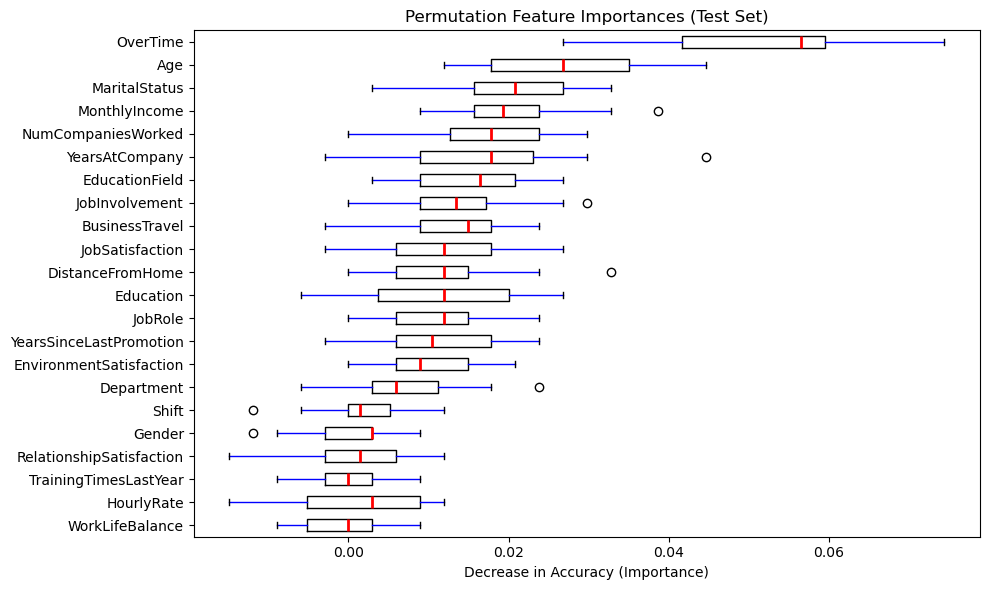

In [131]:
#Run neural network model using permutation feature importance technique since it has same accuracy but higher recall than random forest
from sklearn.inspection import permutation_importance
r = permutation_importance(pipe_nn_update, X_test, y_test,
                           n_repeats=30,
                           random_state=5,
                          scoring = 'accuracy')


# 3. Organize results for plotting
sorted_idx = r.importances_mean.argsort()
# The 'r.importances' attribute contains all the scores from the repetitions
importances = r.importances[sorted_idx].T
feature_names = X_test.columns[sorted_idx]

# 4. Create the box plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot(
    importances,
    vert=False,  # Horizontal box plots are often easier to read for feature names
    labels=feature_names,
    medianprops={"color": "red", "linewidth": 2},
    whiskerprops={"color": "blue"},
)
ax.set_title("Permutation Feature Importances (Test Set)")
ax.set_xlabel("Decrease in Accuracy (Importance)")
fig.tight_layout()
plt.show()

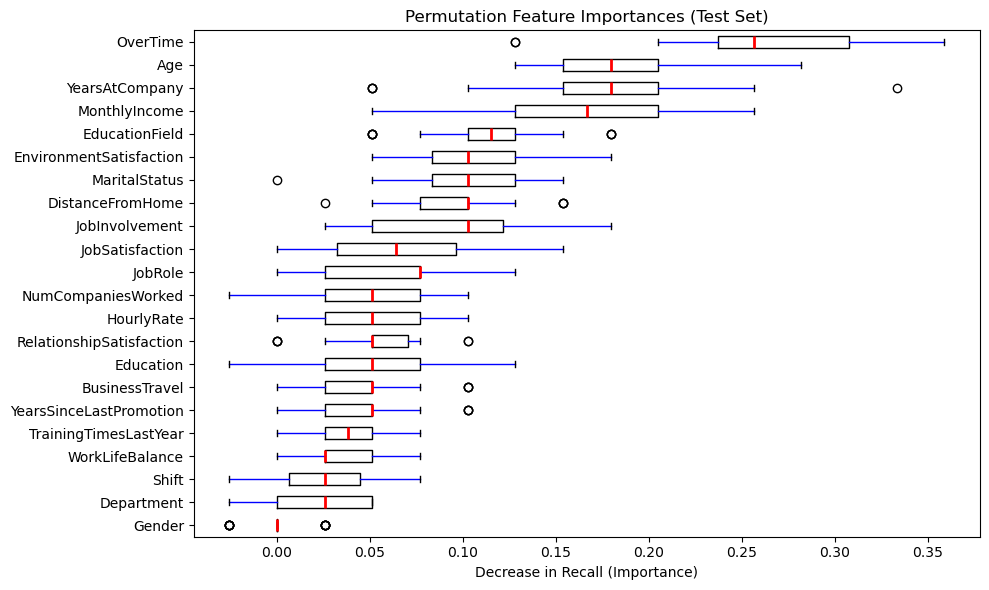

In [132]:
r = permutation_importance(pipe_nn_update, X_test, y_test,
                           n_repeats=30,
                           random_state=5,
                          scoring = 'recall')


# 3. Organize results for plotting
sorted_idx = r.importances_mean.argsort()
# The 'r.importances' attribute contains all the scores from the repetitions
importances = r.importances[sorted_idx].T
feature_names = X_test.columns[sorted_idx]

# 4. Create the box plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot(
    importances,
    vert=False,  # Horizontal box plots are often easier to read for feature names
    labels=feature_names,
    medianprops={"color": "red", "linewidth": 2},
    whiskerprops={"color": "blue"},
)
ax.set_title("Permutation Feature Importances (Test Set)")
ax.set_xlabel("Decrease in Recall (Importance)")
fig.tight_layout()
plt.show()

In [135]:
r = permutation_importance(pipe_nn_update, X_test, y_test,
                           n_repeats=30,
                           random_state=0,
                          scoring = 'accuracy')

for i in r.importances_mean.argsort()[::-1]:
    print(f"{X_test.columns[i]:<8}"
        f" {r.importances_mean[i]:.3f}"
        f" +/- {r.importances_std[i]:.3f}")

OverTime 0.057 +/- 0.011
Age      0.022 +/- 0.011
MonthlyIncome 0.021 +/- 0.010
NumCompaniesWorked 0.020 +/- 0.008
YearsAtCompany 0.018 +/- 0.011
MaritalStatus 0.018 +/- 0.008
BusinessTravel 0.017 +/- 0.005
DistanceFromHome 0.016 +/- 0.007
EducationField 0.015 +/- 0.007
YearsSinceLastPromotion 0.013 +/- 0.008
JobInvolvement 0.013 +/- 0.007
JobSatisfaction 0.012 +/- 0.007
EnvironmentSatisfaction 0.012 +/- 0.006
JobRole  0.012 +/- 0.007
Education 0.012 +/- 0.008
Department 0.007 +/- 0.007
RelationshipSatisfaction 0.004 +/- 0.004
TrainingTimesLastYear 0.003 +/- 0.006
Shift    0.000 +/- 0.005
Gender   0.000 +/- 0.006
HourlyRate -0.000 +/- 0.006
WorkLifeBalance -0.002 +/- 0.004


In [136]:
r = permutation_importance(pipe_nn_update, X_test, y_test,
                           n_repeats=30,
                           random_state=0,
                          scoring = 'recall')

for i in r.importances_mean.argsort()[::-1]:
    print(f"{X_test.columns[i]:<8}"
        f" {r.importances_mean[i]:.3f}"
        f" +/- {r.importances_std[i]:.3f}")

OverTime 0.277 +/- 0.043
YearsAtCompany 0.188 +/- 0.055
Age      0.182 +/- 0.045
MonthlyIncome 0.160 +/- 0.037
EnvironmentSatisfaction 0.116 +/- 0.035
DistanceFromHome 0.108 +/- 0.040
EducationField 0.105 +/- 0.047
MaritalStatus 0.092 +/- 0.033
JobInvolvement 0.092 +/- 0.038
JobRole  0.070 +/- 0.036
BusinessTravel 0.061 +/- 0.022
NumCompaniesWorked 0.057 +/- 0.034
JobSatisfaction 0.056 +/- 0.040
RelationshipSatisfaction 0.051 +/- 0.021
YearsSinceLastPromotion 0.050 +/- 0.029
TrainingTimesLastYear 0.050 +/- 0.029
HourlyRate 0.050 +/- 0.022
Education 0.047 +/- 0.037
WorkLifeBalance 0.028 +/- 0.019
Department 0.022 +/- 0.029
Shift    0.020 +/- 0.027
Gender   -0.003 +/- 0.017


In [141]:
pipe_nn_update

,steps,"[('column_transform', ...), ('adasyn', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('onehotencoder', ...), ('standardscaler', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string

In [241]:
from sklearn.preprocessing import FunctionTransformer

#Update the Pipeline to float values for partial dependence plots 

def int_to_float(df):
    return df.astype('float')

pipe_nn_float = Pipeline(
    steps=[
        ("column_transform", ct),
        ("convert_float", FunctionTransformer(int_to_float)),
        ("adasyn", ADASYN()),
        ("classifier", MLPClassifier(hidden_layer_sizes=(22,), learning_rate_init=0.01, max_iter=1000)),
    ]
)

pipe_nn_float.fit(X_train, y_train)
y_pred_update = pipe_nn_float.predict(X_test)
pipe_nn_float

,steps,"[('column_transform', ...), ('convert_float', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('onehotencoder', ...), ('standardscaler', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a

In [173]:
X_test.columns

Index(['Age', 'BusinessTravel', 'Department', 'DistanceFromHome', 'Education',
       'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'NumCompaniesWorked', 'OverTime',
       'RelationshipSatisfaction', 'Shift', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsSinceLastPromotion'],
      dtype='object')

/opt/anaconda3/lib/python3.12/site-packages/sklearn/inspection/_partial_dependence.py:721: FutureWarning: The column 0 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/inspection/_partial_dependence.py:721: FutureWarning: The column 3 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/inspection/_partial_dependence.py:721:

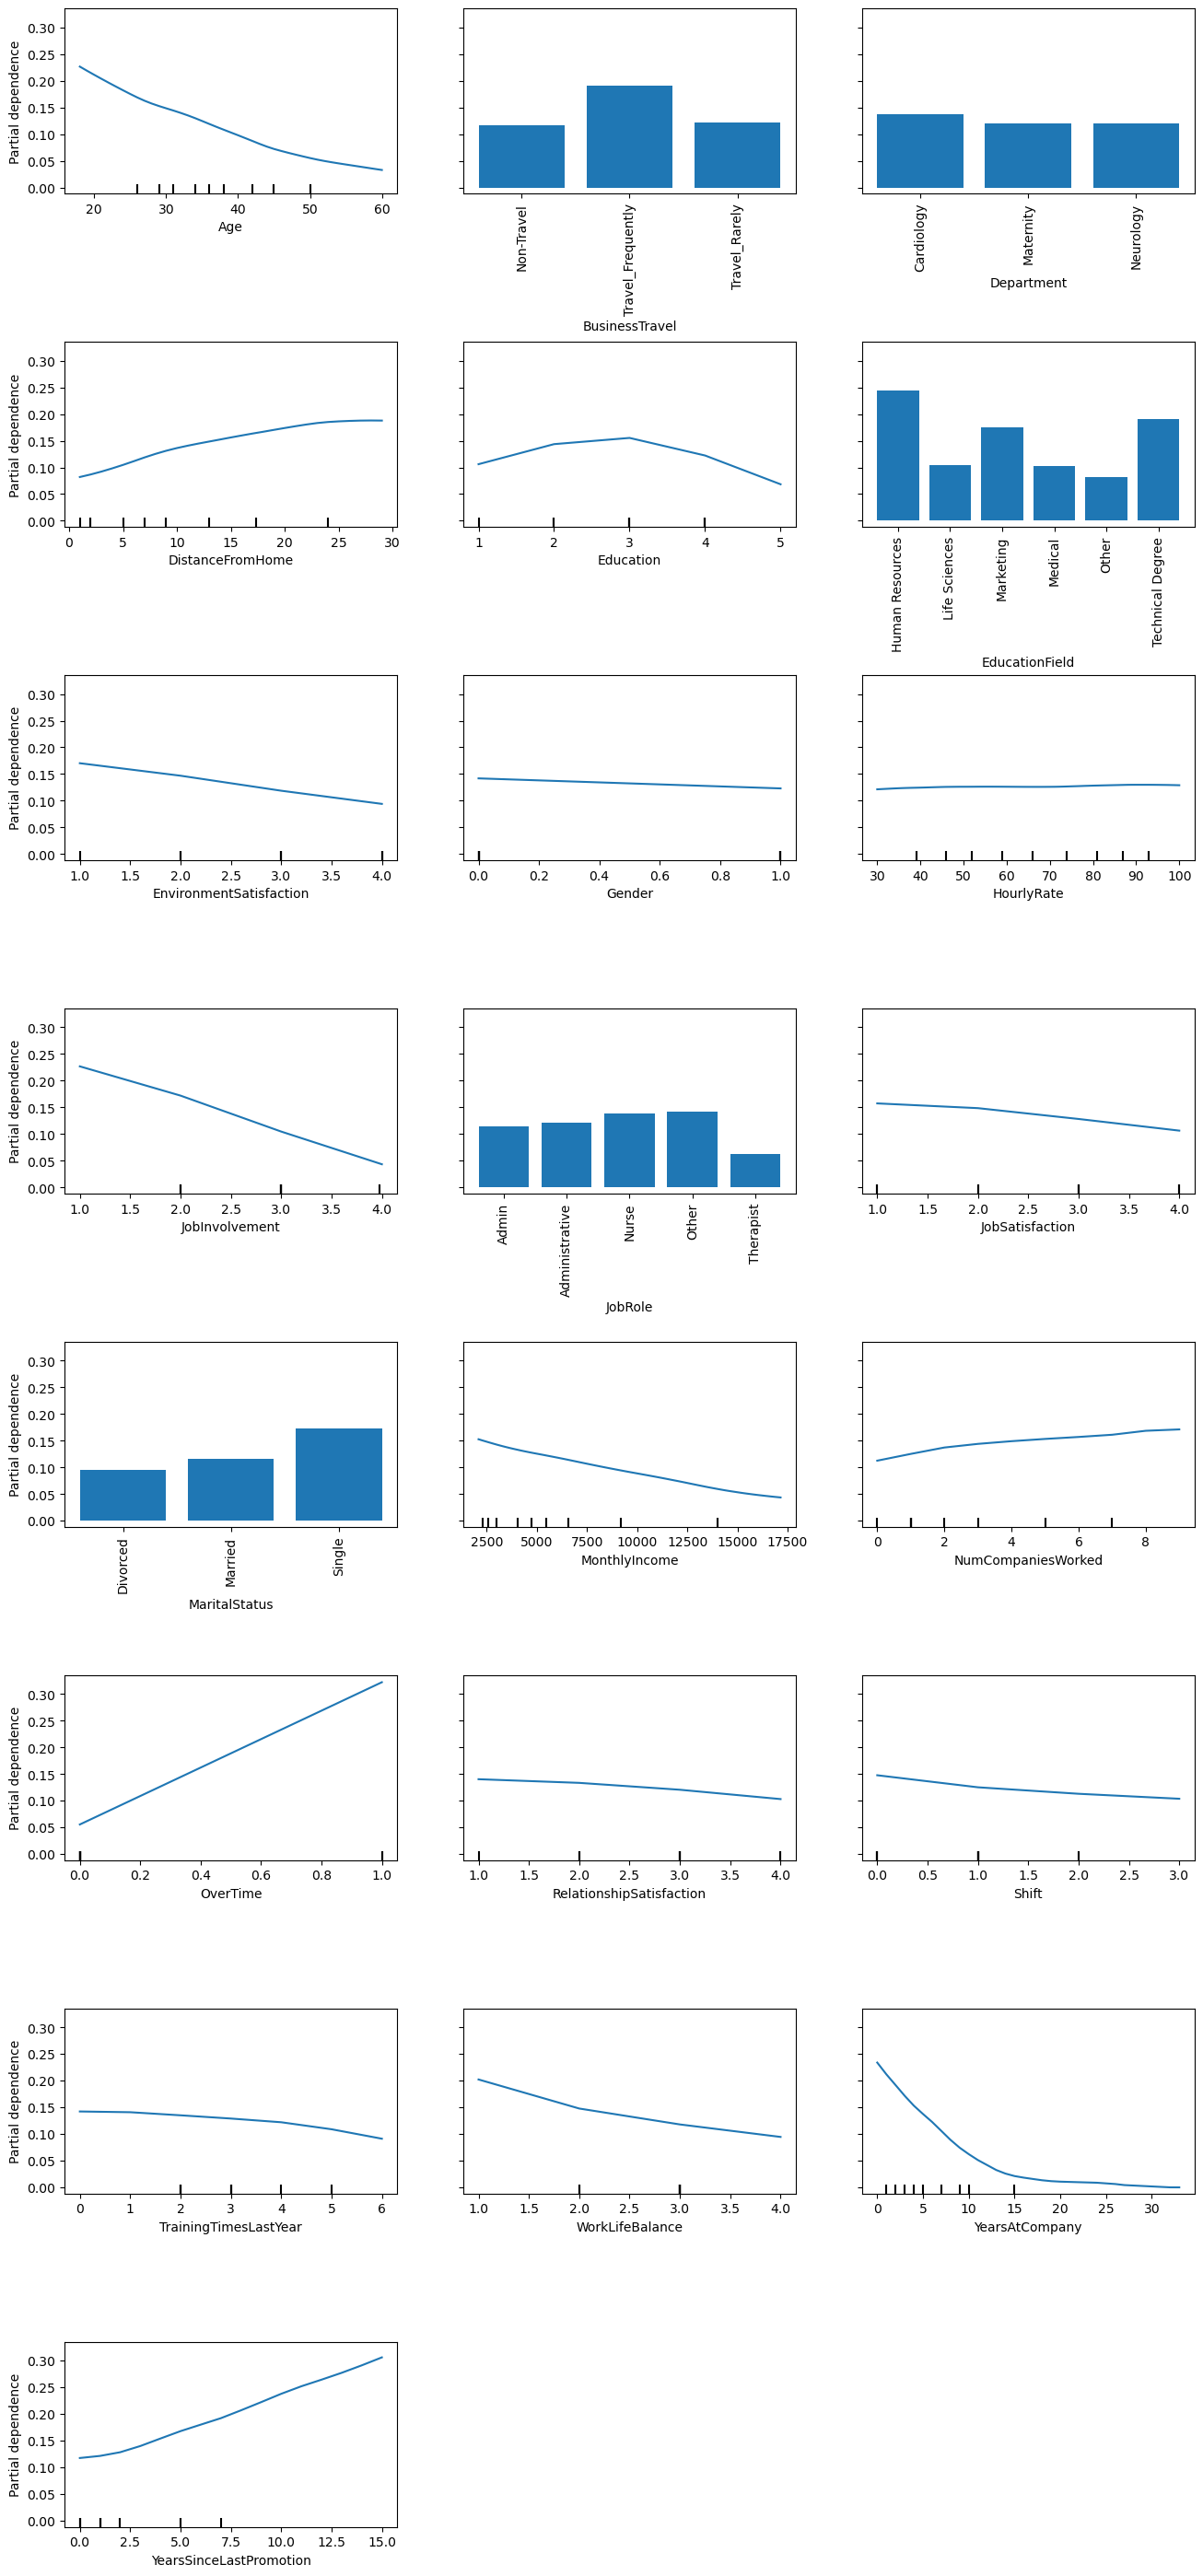

In [237]:
from sklearn.inspection import PartialDependenceDisplay

features = X_test.columns
fig, ax = plt.subplots(figsize=(15, 30))
fig.subplots_adjust(wspace=0.2, hspace=0.8)
PartialDependenceDisplay.from_estimator(pipe_nn_float, X_test, features, categorical_features = ['BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus'], ax=ax)
fig.tight_layout(pad=8.0)
plt.show()